In [2]:
from collections import defaultdict
import community as community_louvain
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import numpy as np
import random
import ast

# Exercise 3: Zachary’s karate club:
In this exercise, we will work on Zarachy’s karate club graph (refer to the Introduction of Chapter 9). The dataset is available in NetworkX, by calling the function karate_club_graph

Node Degree
   0     16 Mr. Hi
   1      9 Mr. Hi
   2     10 Mr. Hi
   3      6 Mr. Hi
   4      3 Mr. Hi
   5      4 Mr. Hi
   6      4 Mr. Hi
   7      4 Mr. Hi
   8      5 Mr. Hi
   9      2 Officer
  10      3 Mr. Hi
  11      1 Mr. Hi
  12      2 Mr. Hi
  13      5 Mr. Hi
  14      2 Officer
  15      2 Officer
  16      2 Mr. Hi
  17      2 Mr. Hi
  18      2 Officer
  19      3 Mr. Hi
  20      2 Officer
  21      2 Mr. Hi
  22      2 Officer
  23      5 Officer
  24      3 Officer
  25      3 Officer
  26      2 Officer
  27      4 Officer
  28      3 Officer
  29      4 Officer
  30      4 Officer
  31      6 Officer
  32     12 Officer
  33     17 Officer


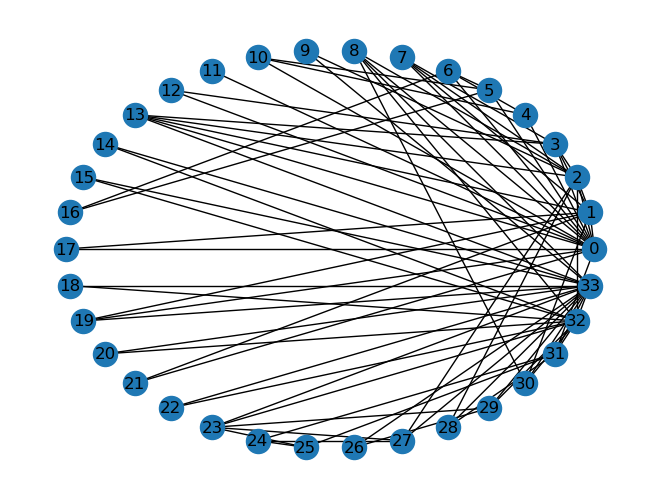

In [3]:
G = nx.karate_club_graph()
print("Node Degree")
for v in G:
    print(f"{v:4} {G.degree(v):6} {G.nodes[v]['club']}")

nx.draw_circular(G, with_labels=True)
plt.show()

1. Visualize the graph. Set the color of each node based on the club split (the information is stored as a node attribute). My version of the visualization is below.

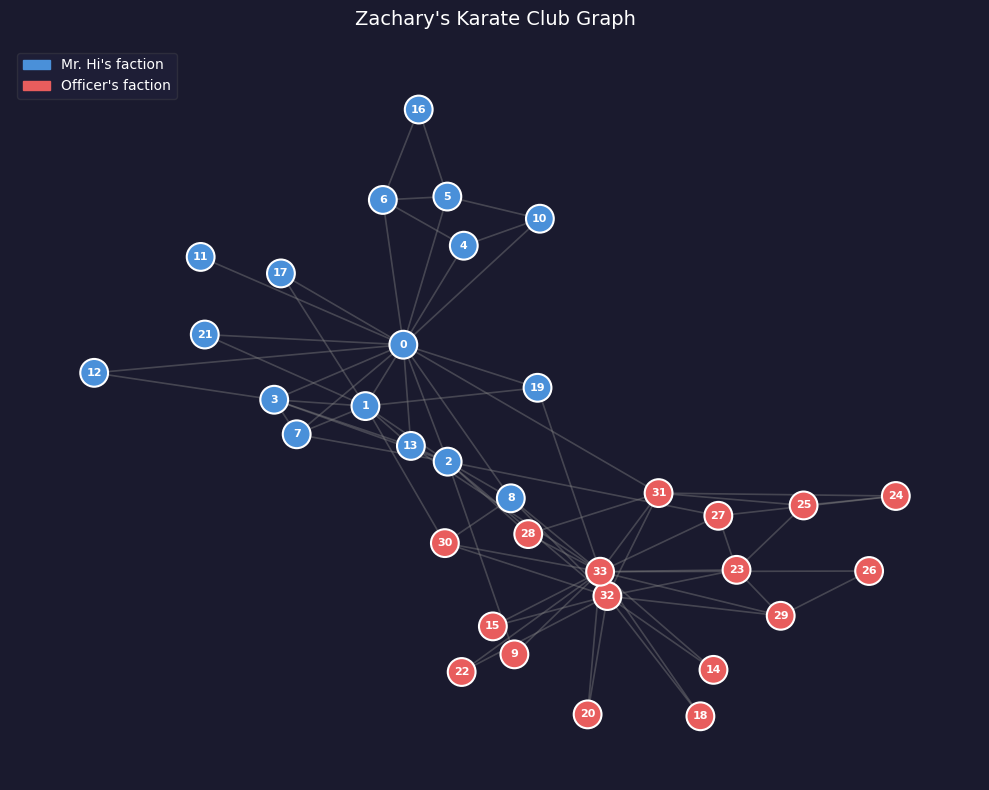

In [4]:
# Assign colors based on club split
color_map = []
for node in G.nodes():
    club = G.nodes[node]['club']
    if club == 'Mr. Hi':
        color_map.append('#4A90D9')
    else:
        color_map.append('#E85D5D')

# Use spring layout for a clean look
pos = nx.spring_layout(G, seed=42)

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

# Draw edges
nx.draw_networkx_edges(
    G, pos,
    edge_color='#888888',
    alpha=0.4,
    width=1.2,
    ax=ax
)

# Draw nodes
nx.draw_networkx_nodes(
    G, pos,
    node_color=color_map,
    node_size=400,
    edgecolors='white',
    linewidths=1.5,
    ax=ax
)

# Draw labels
nx.draw_networkx_labels(
    G, pos,
    font_size=8,
    font_color='white',
    font_weight='bold',
    ax=ax
)

# Legend
mr_hi_patch = mpatches.Patch(color='#4A90D9', label="Mr. Hi's faction")
officer_patch = mpatches.Patch(color='#E85D5D', label="Officer's faction")
legend = ax.legend(
    handles=[mr_hi_patch, officer_patch],
    loc='upper left',
    framealpha=0.3,
    facecolor='#2a2a4a',
    edgecolor='#555',
    labelcolor='white',
    fontsize=10
)

ax.set_title("Zachary's Karate Club Graph", color='white', fontsize=14, pad=15)
ax.axis('off')

plt.tight_layout()
plt.savefig('karate_club_graph.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
plt.close()


2. Write a function to compute the modularity of a graph partitioning (use equation 9.12 in the book). The function should take a networkX Graph and a partitioning as inputs and return the modularity.

In [5]:
def compute_modularity(G, partition):
    L = G.number_of_edges()
    degrees = dict(G.degree())
    nodes = list(G.nodes())
    
    M = 0
    for i in nodes:
        for j in nodes:
            if partition[i] == partition[j]:
                k_i = degrees[i]
                k_j = degrees[j]
                A_ij = 1 if G.has_edge(i, j) else 0
                M += A_ij - (k_i * k_j) / (2 * L)
    
    return M / (2 * L)

3. Explain in your own words the concept of modularity.

Modularity is a way of measuring how good a community split of a network is.
The core idea is that in a random network, edges are distributed randomly between nodes. So if you split a random network into groups, the number of edges within groups versus between groups would just be proportional to chance, determined by how many edges each node has.
Modularity compares your actual network against this random baseline. For each pair of nodes in the same community, it asks weather there is more connection here than you'd expect by chance? If yes, that's evidence of real community structure.

4. Compute the modularity of the Karate club split partitioning using the function you just wrote. Note: the Karate club split partitioning is avilable as a node attribute, called “club”.

In [6]:
partition = {v: 0 if G.nodes[v]['club'] == 'Mr. Hi' else 1 for v in G.nodes()}

print(compute_modularity(G, partition))

0.3582347140039433


For the karate club, the true split scores ~0.36, which indicates reasonably strong community structure.

5. Create 1000 randomized version of the Karate Club network using the double edge swap algorithm you wrote in the exercise above 5. For each of them, compute the modularity of the “club” split and store it in a list.

In [7]:
def double_edge_swap(G):
    G_copy = G.copy()
    edges = list(G_copy.edges())
    E = len(edges)
    num_swaps = E * 10
    swaps_done = 0
    while swaps_done < num_swaps:
        e1, e2 = random.sample(edges, 2)
        a, b = e1
        c, d = e2
        
        if random.random() < 0.5:
            a, b = b, a
        
        if len(set([a, b, c, d])) == 4:
            if not G_copy.has_edge(a, d) and not G_copy.has_edge(c, b):
                G_copy.remove_edge(*e1)
                G_copy.remove_edge(*e2)
                G_copy.add_edge(a, d)
                G_copy.add_edge(c, b)
                edges.remove(e1)
                edges.remove(e2)
                edges.append((a, d))
                edges.append((c, b))
                swaps_done += 1
    return G_copy

In [8]:
rkc = []
for i in range(1000):
    G_random = double_edge_swap(G)
    mod = compute_modularity(G_random, partition)
    rkc.append(mod)
rkc

[-0.02638067061143968,
 0.024901380670611484,
 -0.05202169625246535,
 0.050542406311637436,
 -0.026380670611439838,
 0.050542406311637415,
 -0.026380670611439668,
 -0.026380670611439838,
 -0.05202169625246514,
 -0.05202169625246514,
 0.05054240631163746,
 0.024901380670611595,
 -0.026380670611439748,
 -0.026380670611439828,
 -0.000739644970414183,
 -0.026380670611439692,
 -0.05202169625246524,
 -0.05202169625246528,
 -0.026380670611439817,
 -0.10330374753451634,
 0.02490138067061141,
 -0.07766272189349067,
 0.05054240631163713,
 -0.02638067061143979,
 -0.0007396449704141487,
 -0.0007396449704141943,
 -0.026380670611439647,
 -0.026380670611439623,
 -0.10330374753451636,
 -0.0007396449704142114,
 -0.07766272189349073,
 -0.0007396449704141317,
 -0.0007396449704141914,
 -0.0263806706114398,
 -0.05202169625246521,
 -0.0007396449704142227,
 -0.0776627218934907,
 0.024901380670611598,
 -0.0007396449704141744,
 -0.000739644970414143,
 -0.026380670611439772,
 0.05054240631163739,
 -0.0007396449

6. Compute the average and standard deviation of the modularity for the random network.

In [9]:
print(f"Mean: {np.mean(rkc):.4f}")
print(f"Std:  {np.std(rkc):.4f}")

Mean: -0.0161
Std:  0.0497


7. Plot the distribution of the “random” modularity. Plot the actual modularity of the club split as a vertical line (use axvline).

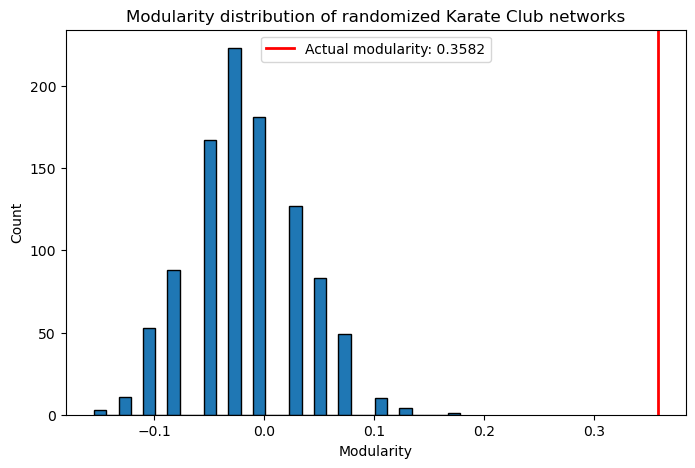

In [10]:
actual_mod = compute_modularity(G, partition)

plt.figure(figsize=(8, 5))
plt.hist(rkc, bins=30, edgecolor='black')
plt.axvline(actual_mod, color='red', linewidth=2, label=f'Actual modularity: {actual_mod:.4f}')
plt.xlabel('Modularity')
plt.ylabel('Count')
plt.title('Modularity distribution of randomized Karate Club networks')
plt.legend()
plt.show()

8. Comment on the figure. Is the club split a good partitioning? Why do you think I asked you to perform a randomization experiment? What is the reason why we preserved the nodes degree?

Is the club split a good partitioning?
Yes, the actual modularity of 0.358 is far outside the distribution of random networks, which is centered around 0. This means the two-club split captures real community structure that is extremely unlikely to arise by chance.

Why the randomization experiment?
Modularity alone doesn't tell you much, you need a baseline to compare against. A modularity of 0.358 might sound good, but good compared to what? The randomization experiment provides that baseline. By generating 1000 random networks and computing modularity for each, we can ask: how likely is it that we'd see this modularity just by chance? Since none of the 1000 random networks came close to 0.358, we can confidently say the community structure is statistically significant and not a fluke.

Why preserve node degrees?
Because degree is a fundamental property of each node, it reflects how socially active each member was. If we randomized without preserving degrees, we'd be creating networks that are structurally very different from the original, making the comparison unfair. By preserving degrees, the only thing that changes between the original and the random networks is who is connected to whom, not how many connections each person has. This isolates community structure as the one variable being tested.

9. Use the Python Louvain-algorithm implementation to find communities in this graph. Report the value of modularity found by the algorithm. Is it higher or lower than what you found above for the club split? What does this comparison reveal?

In [11]:
louvain_partition = community_louvain.best_partition(G)
louvain_mod = compute_modularity(G, louvain_partition)

print(f"Louvain modularity:    {louvain_mod:.4f}")
print(f"Club split modularity: {compute_modularity(G, partition):.4f}")
print(f"Number of communities: {max(louvain_partition.values()) + 1}")

Louvain modularity:    0.3991
Club split modularity: 0.3582
Number of communities: 3


10. Compare the communities found by the Louvain algorithm with the club split partitioning by creating a matrix D with dimension (2 times A), where A is the number of communities found by Louvain. We set entry D(i,j) to be the number of nodes that community i has in common with group split j. The matrix D is what we call a confusion matrix. Use the confusion matrix to explain how well the communities you’ve detected correspond to the club split partitioning.

In [12]:
# Number of communities found by Louvain
A = max(louvain_partition.values()) + 1

# Build confusion matrix (A x 2)
D = np.zeros((A, 2), dtype=int)

for node in G.nodes():
    louvain_community = louvain_partition[node]
    club_split = partition[node]  # 0 for Mr. Hi, 1 for Officer
    D[louvain_community][club_split] += 1

print("Confusion Matrix (rows=Louvain communities, cols=club split)")
print("           Mr. Hi  Officer")
for i, row in enumerate(D):
    print(f"Community {i}: {row[0]:5d}  {row[1]:6d}")

Confusion Matrix (rows=Louvain communities, cols=club split)
           Mr. Hi  Officer
Community 0:    11       0
Community 1:     1      17
Community 2:     5       0


So Louvain found 3 communities instead of 2, but it split Mr. Hi's faction into two subgroups (Community 0 and Community 2) rather than mixing the two factions. The Officer's faction was kept almost perfectly intact.
This is a strong result, only 1 node out of 34 was placed in the "wrong" group relative to the true split. The Louvain algorithm essentially recovers the true factional divide almost perfectly from edge structure alone, without any knowledge of the real-world outcome. The fact that Mr. Hi's group gets split in two suggests there is genuine substructure within that faction, perhaps a smaller clique of members who were more tightly connected to each other than to the rest of Mr. Hi's followers.